# Spatial Analysis of ZüriWieNeu Reports

In [1]:
import geopandas as gpd
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


DATA_PROCESSED = Path("../data/processed")
OUTPUTS = Path("../outputs")

In [2]:
reports_quartiere_clean = gpd.read_file(
    DATA_PROCESSED / "reports_quartiere_clean.gpkg"
)

quartiere_merge = gpd.read_file(
    DATA_PROCESSED / "quartiere_merge.gpkg"
)

## Reports per Quartier

In [3]:
reports_per_quartier = (
    reports_quartiere_clean
    .groupby("quartier_name")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="report_count")
)
reports_per_quartier

,quartier_name,report_count
0,Saatlen,6222
1,Hottingen,5273
2,Wollishofen,4136
3,Hochschulen,3611
4,Lindenhof,3334
5,City,3110
6,Werd,3001
7,Witikon,2880
8,Schwamendingen-Mitte,2861
9,Wipkingen,2767


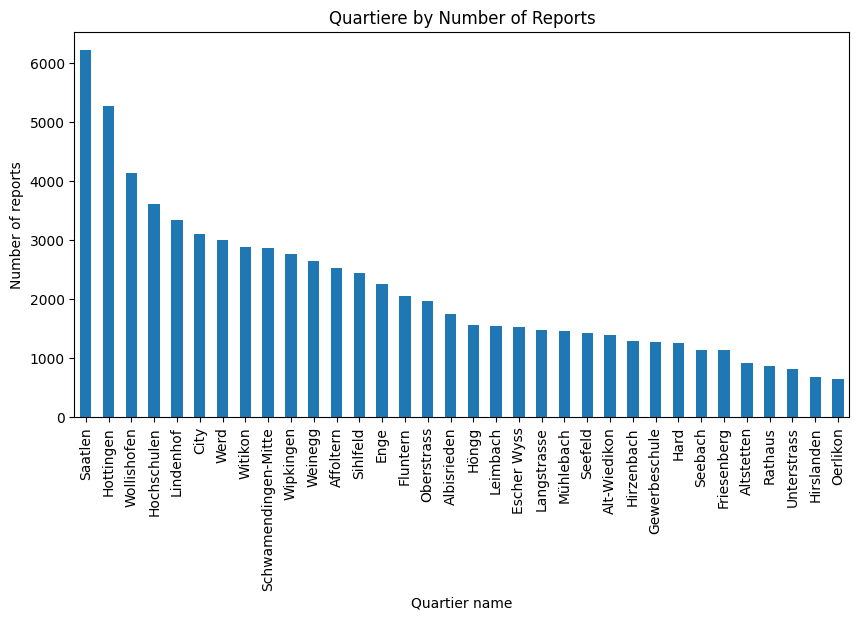

In [4]:
reports_per_quartier.plot(
    kind="bar",
    figsize=(10,5),
    x="quartier_name",
    y="report_count",
    legend=False
)

plt.xlabel("Quartier name")
plt.ylabel("Number of reports")
plt.title("Quartiere by Number of Reports")
plt.show()

In [5]:
reports_per_quartier_map = quartiere_merge.merge(
    reports_per_quartier,
    left_on="name",
    right_on="quartier_name",
    how="left"
)

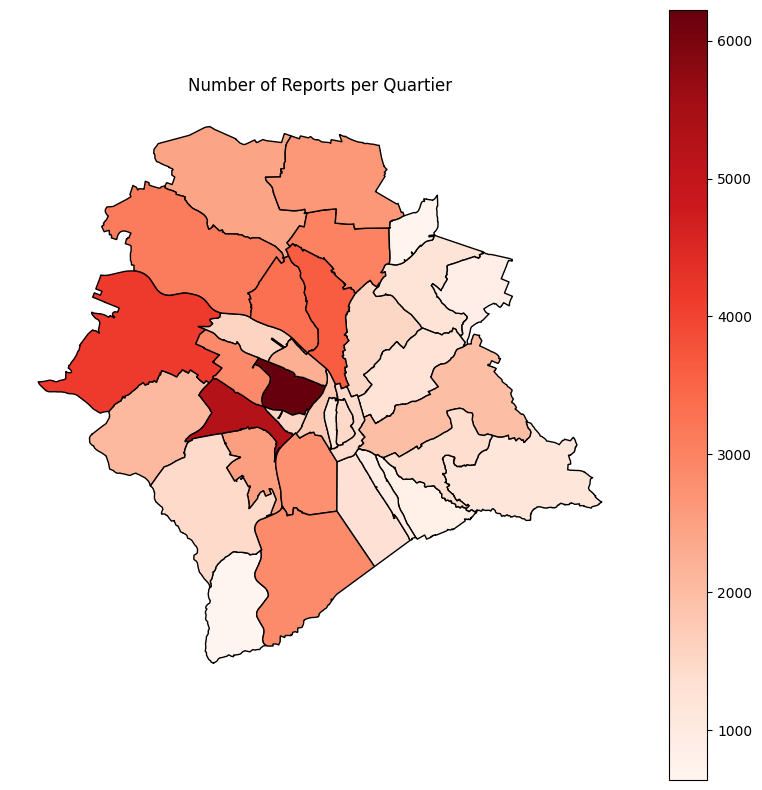

In [6]:
reports_per_quartier_map.plot(
    column="report_count",
    cmap="Reds",
    legend=True,
    figsize=(10,10),
    edgecolor="black"
)

plt.title("Number of Reports per Quartier")
plt.axis("off")
plt.savefig(
    OUTPUTS / "reports_per_quartier_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Most Common Report Categories

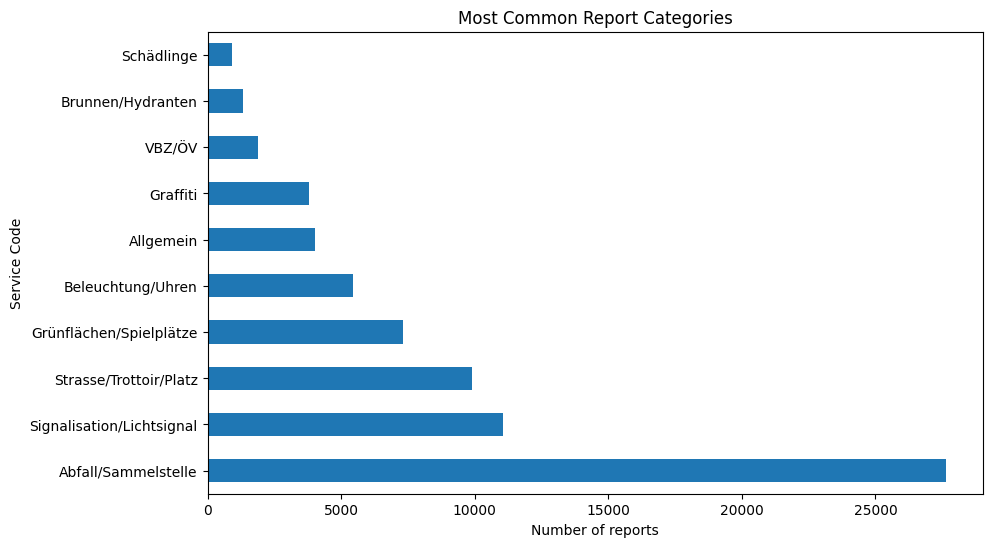

In [7]:
reports_quartiere_clean["service_code"].value_counts().plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("Number of reports")
plt.ylabel("Service Code")
plt.title("Most Common Report Categories")
plt.savefig(
    OUTPUTS / "most_common_report_categories_barplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Most Common Report Categories per Quartier

In [8]:
category_counts = (
    reports_quartiere_clean
        .groupby(
            ["quartier_name", "service_code"]
        )
        .size()
        .reset_index(name="count")
)
category_counts.head()

,quartier_name,service_code,count
0,Affoltern,Abfall/Sammelstelle,1293
1,Affoltern,Allgemein,149
2,Affoltern,Beleuchtung/Uhren,169
3,Affoltern,Brunnen/Hydranten,30
4,Affoltern,Graffiti,41


In [9]:
top_categories = (
    category_counts
    .sort_values(
        ["quartier_name", "count"],
        ascending=[True, False]
    )
    .groupby("quartier_name")
    .head(3)
)

In [10]:
category_plot = top_categories.pivot(
    index="quartier_name",
    columns="service_code",
    values="count"
).fillna(0)

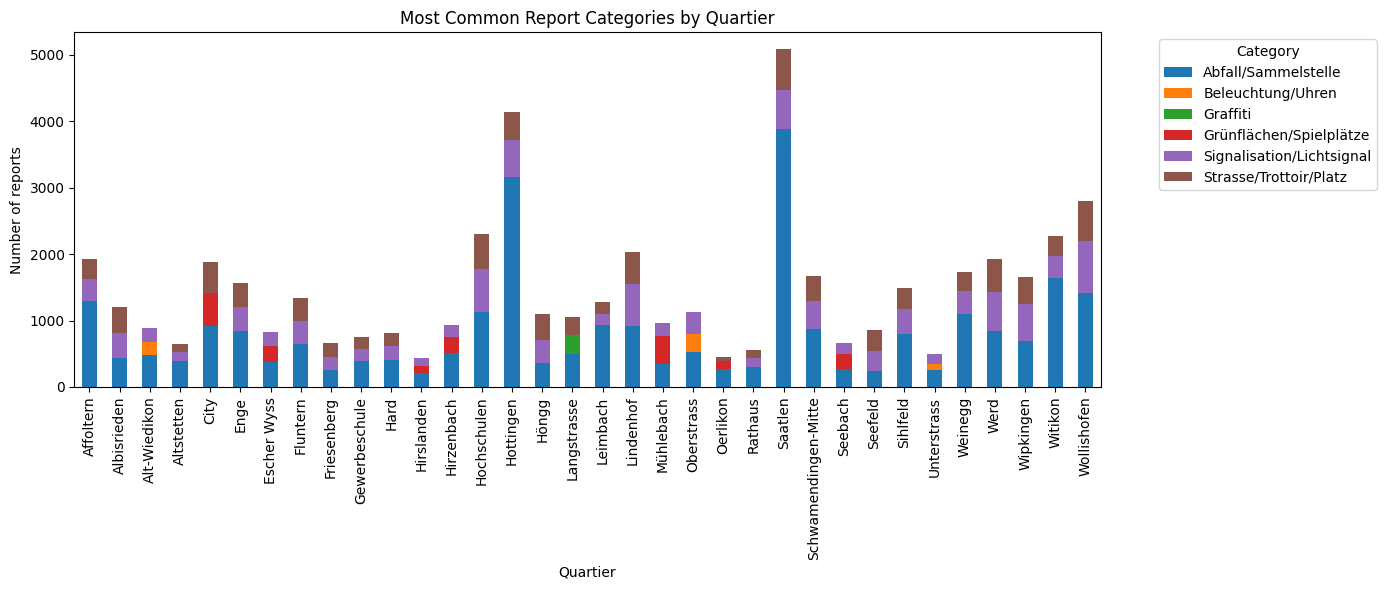

In [11]:
category_plot.plot (
    kind = "bar",
    stacked = True,
    figsize= (14,6)
)

plt.xlabel("Quartier")
plt.ylabel("Number of reports")
plt.title("Most Common Report Categories by Quartier")

plt.legend(
    title = "Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(
    OUTPUTS / "common_report_categories_by_quartier_barplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [12]:
main_category = (
    category_counts
    .sort_values(
        "count",
        ascending=False
    )
    .groupby("quartier_name")
    .first()
    .reset_index()
)

In [13]:
quartiere_main = quartiere_merge.merge(
    main_category,
    left_on="name",
    right_on="quartier_name"
)

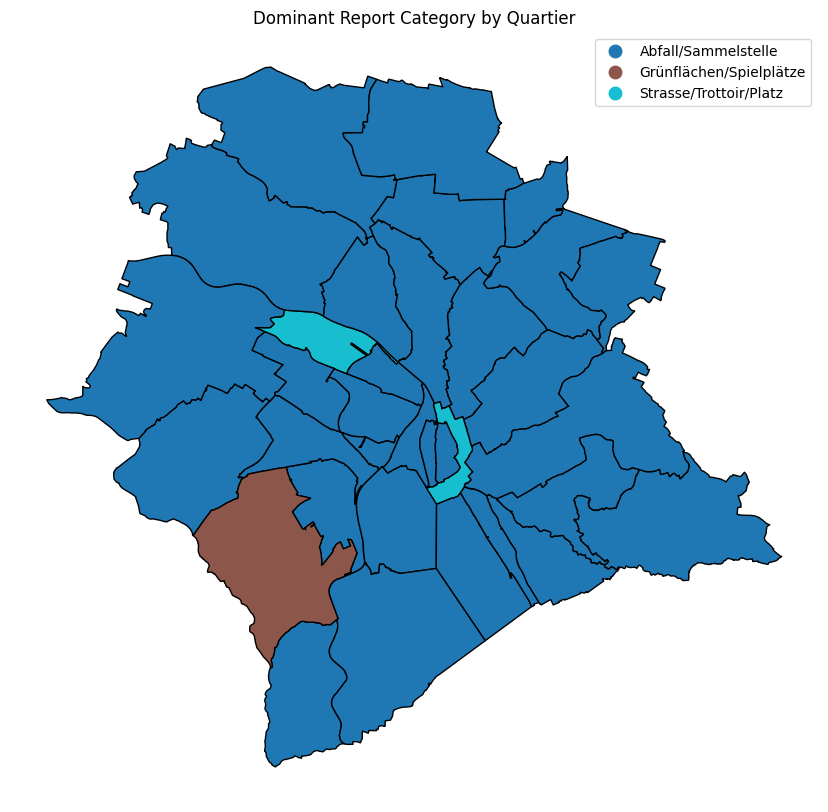

In [14]:
quartiere_main.plot(
    column="service_code",
    figsize=(12,10),
    legend=True,
    edgecolor="black"
)

plt.title("Dominant Report Category by Quartier")
plt.axis("off")
plt.savefig(
    OUTPUTS / "dominant_report_category_by_quartier_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Reports over Time

In [15]:
monthly_reports = (
    reports_quartiere_clean
    .set_index("requested_datetime")
    .groupby("month")
    .size()
)

KeyError: 'month'

In [ ]:
monthly_reports.plot(
    figsize=(14,5)
)

plt.xlabel("Year")
plt.ylabel("Number of reports")
plt.title("Number of ZüriWieNeu Reports over the Years")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    OUTPUTS / "number_of_reports_over_time_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()